In [10]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for our charts later
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
# Cell 2: Load the dataset using the actual CSV path
file_path = r"C:\Users\lenovo\OneDrive\Documents\5th sem RCF research project\Rainfall_Classification_Project\Data\Raw\Rainfall_India.csv\UP_rainfall_dataset.csv"
df = pd.read_csv(file_path)

# -------------------------------------------------------------
# RESEARCH STEP: TARGET VARIABLE ENGINEERING
# We define a "Rainy Day" as any day with more than 0.1 mm of rain.
# 1 = Rain, 0 = No Rain
# -------------------------------------------------------------
df['RainToday'] = (df['PRECTOTCORR'] > 0.1).astype(int)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,YEAR,MO,DY,RH2M,T2MDEW,QV2M,PS,WS50M,PRECTOTCORR,T2MWET,...,T2M_MAX,T2M_MIN,ALLSKY_SFC_UV_INDEX,TS,PSC,WSC,DISTRICT,LATITUDE,LONGITUDE,RainToday
0,2005,1,1,56.63,9.67,7.63,99.55,3.66,0.34,14.17,...,26.69,14.08,0.41,19.15,90.24,5.07,Agra,27.17,78.04,1
1,2005,1,2,57.34,8.98,7.23,99.60,2.36,0.01,13.76,...,26.16,11.26,0.46,17.76,90.29,3.27,Agra,27.17,78.04,0
2,2005,1,3,55.19,6.25,6.12,99.79,4.27,0.33,11.35,...,24.76,10.65,0.32,16.40,90.39,5.91,Agra,27.17,78.04,1
3,2005,1,4,44.92,0.88,4.06,100.10,4.69,0.00,7.28,...,23.37,6.56,0.62,13.72,90.58,6.50,Agra,27.17,78.04,0
4,2005,1,5,45.51,0.88,4.07,99.94,4.05,0.00,7.24,...,23.25,5.76,0.65,13.55,90.43,5.61,Agra,27.17,78.04,0


In [12]:
# Cell 3: Data Types and Missing Values Overview
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565210 entries, 0 to 565209
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 565210 non-null  int64  
 1   MO                   565210 non-null  int64  
 2   DY                   565210 non-null  int64  
 3   RH2M                 565210 non-null  float64
 4   T2MDEW               565210 non-null  float64
 5   QV2M                 565210 non-null  float64
 6   PS                   565210 non-null  float64
 7   WS50M                565210 non-null  float64
 8   PRECTOTCORR          565210 non-null  float64
 9   T2MWET               565210 non-null  float64
 10  WD50M                565210 non-null  float64
 11  T2M_MAX              565210 non-null  float64
 12  T2M_MIN              565210 non-null  float64
 13  ALLSKY_SFC_UV_INDEX  565210 non-null  float64
 14  TS                   565210 non-null  fl

In [14]:
# Cell 4: Check for Duplicate Records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicates}")


Number of duplicate rows in the dataset: 7638


In [18]:
# Cell 5: Remove duplicates
df = df.drop_duplicates()
print(f"Duplicates removed! New dataset shape: {df.shape}")

Duplicates removed! New dataset shape: (557572, 21)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_23508\1464701803.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RainToday', palette='viridis')


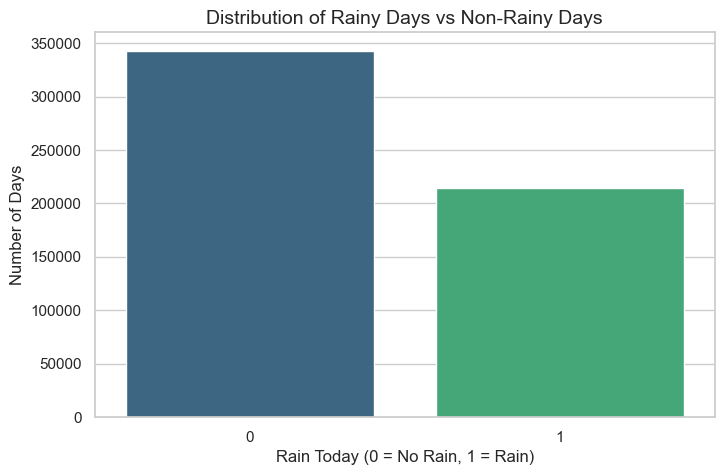

In [19]:
# Cell 6: Target Variable Distribution (Count Plot)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='RainToday', palette='viridis')

plt.title('Distribution of Rainy Days vs Non-Rainy Days', fontsize=14)
plt.xlabel('Rain Today (0 = No Rain, 1 = Rain)', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)

plt.show()

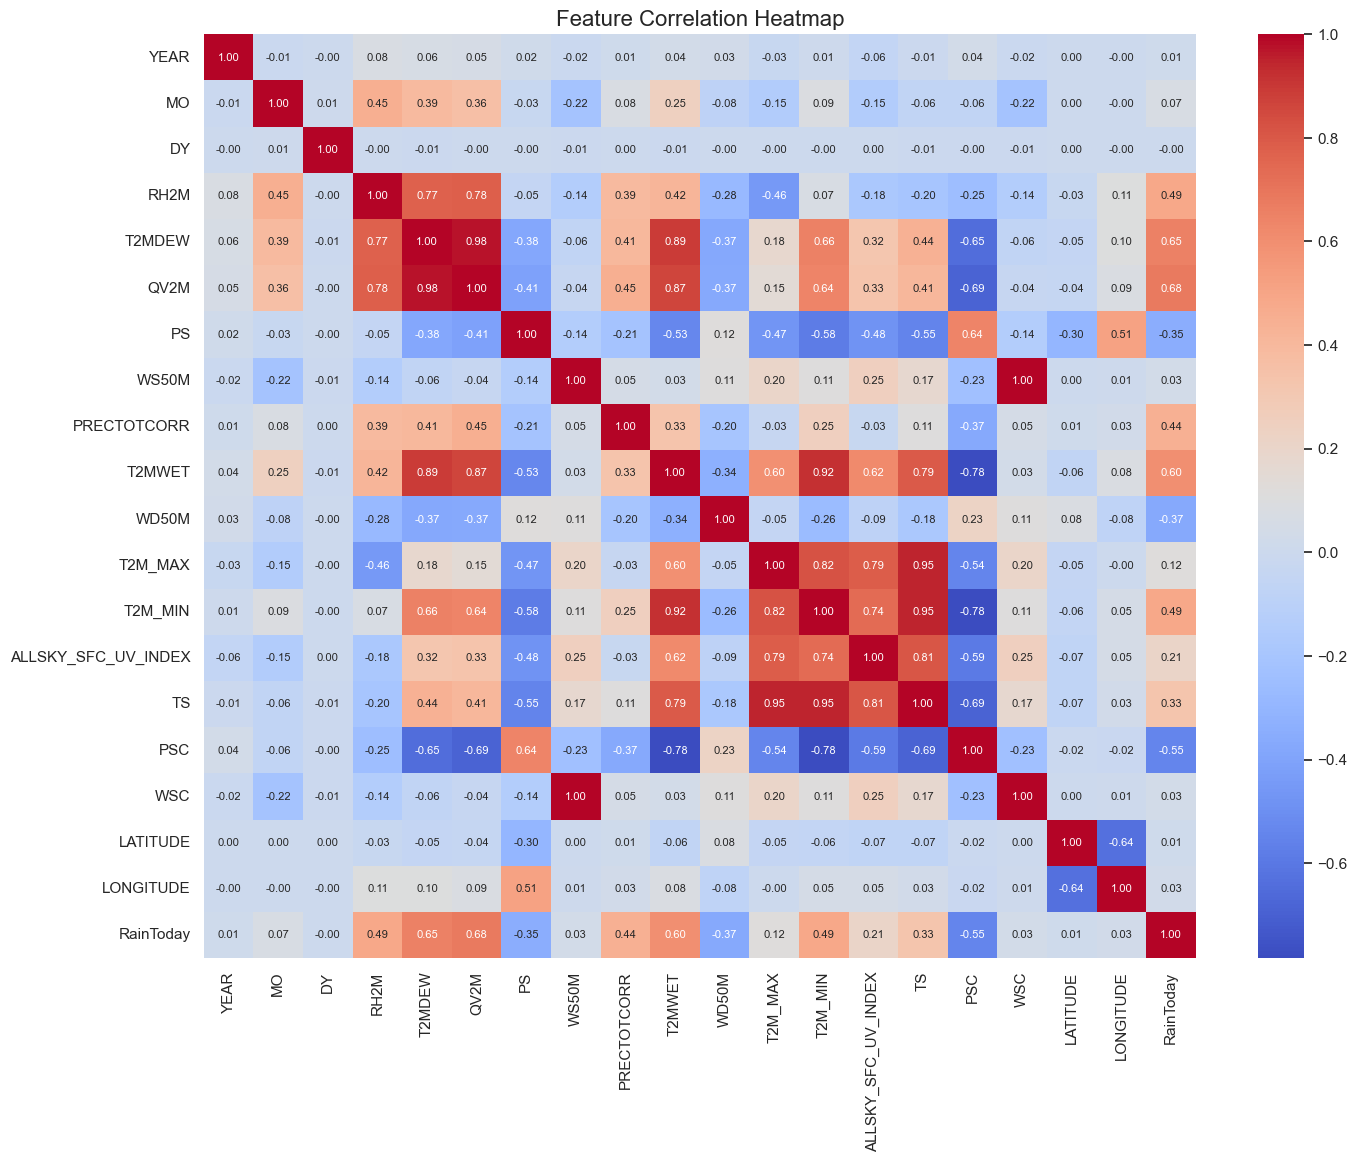

In [21]:
# Cell 7: Correlation Heatmap
plt.figure(figsize=(16, 12))

# We drop non-numeric columns (like 'DISTRICT') so the math works
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
corr_matrix = numeric_df.corr()

# Generate the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws={"size": 8})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_23508\2880631900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RainToday', y='QV2M', palette='Set2')


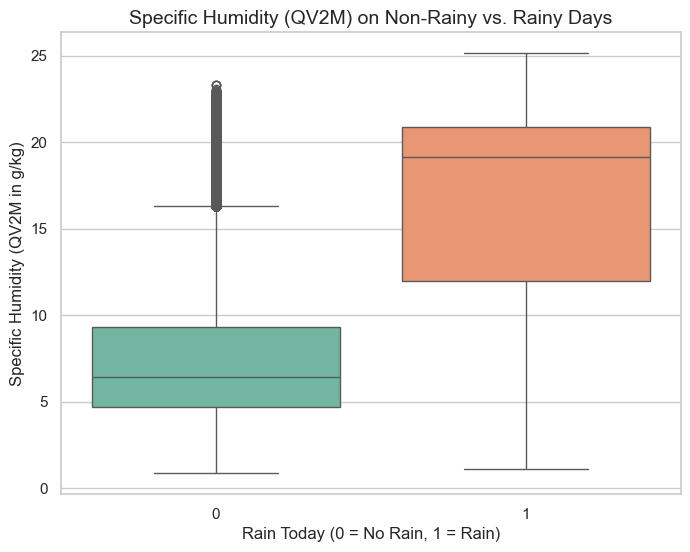

In [23]:
# Cell 8: Boxplot of Specific Humidity vs. Rain
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='RainToday', y='QV2M', palette='Set2')

plt.title('Specific Humidity (QV2M) on Non-Rainy vs. Rainy Days', fontsize=14)
plt.xlabel('Rain Today (0 = No Rain, 1 = Rain)', fontsize=12)
plt.ylabel('Specific Humidity (QV2M in g/kg)', fontsize=12)

plt.show()

In [25]:
# Cell 9: Feature Selection and Train-Test Split
from sklearn.model_selection import train_test_split

# 1. Drop the target variable and non-predictive/categorical columns
# We drop YEAR, MO, DY, and DISTRICT as weather physics depend on sensor data, not names/dates.
# We also drop PRECTOTCORR because it's the actual rainfall amount (which tells us the answer!).
X = df.drop(columns=['RainToday', 'PRECTOTCORR', 'YEAR', 'MO', 'DY', 'DISTRICT'])

# 2. Isolate the target variable
y = df['RainToday']

# 3. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Data Split Successful ---")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

--- Data Split Successful ---
Training Features Shape: (446057, 15)
Testing Features Shape: (111515, 15)


In [26]:
# Cell 10: Train the Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model (using 50 trees to balance speed and accuracy)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training the model... (Please wait, this might take a minute!)")
rf_model.fit(X_train, y_train)

# Make predictions on the hidden test set
y_pred = rf_model.predict(X_test)

# Calculate and display the final accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Model Evaluation ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Training the model... (Please wait, this might take a minute!)

--- Model Evaluation ---
Model Accuracy: 93.25%
